> **AI-generated.** An AI assistant drafted this page, and no maintainer has reviewed it yet. Please report errors on the issue tracker.

# Tutorial 1: A model of the moose counts

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/tutorials/01_first_analysis.ipynb)

Every year from 1967 to 1988, a survey counted the moose in one population.
The tutorials follow one analysis of those counts, from a first model to forecasts that update as each new count arrives.
This tutorial builds the first model and asks what it implies before it sees the data.

It introduces three of the ideas of [how ProbPipe works](../index.md#how-it-works):

1. **Mathematical objects:** a distribution and a conditional distribution are objects that name their components.
2. **One vocabulary of operations:** the same operations, such as `mean`, `sample`, and `condition_on`, apply to every object that supports them.
3. **Computation from capabilities:** an operation computes its result exactly when the object allows it, and it reports how it computed it.

In [1]:
# On Google Colab, install ProbPipe and download the data; elsewhere this cell does nothing.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    import urllib.request

    %pip install --quiet "probpipe-core @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/TARPS-group/prob-pipe/dev/overhaul/"
        "docs/tutorials/data/moose.csv",
        "data/moose.csv",
    )

In [2]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

from probpipe import (
    Beta,
    LogNormal,
    Poisson,
    condition_on,
    conditional_distribution,
    mean,
    quantile,
    sample,
    workflow_run,
)

# TensorFlow Probability warns that JAX runs in 32-bit precision, which these models use.
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype float64")

## 1. The counts

The counts come from the course materials of Dietze's *Ecological Forecasting* (2017).
Each one is the number of animals the survey found, which is smaller than the population.

years: 1967 to 1988
number of counts: 22


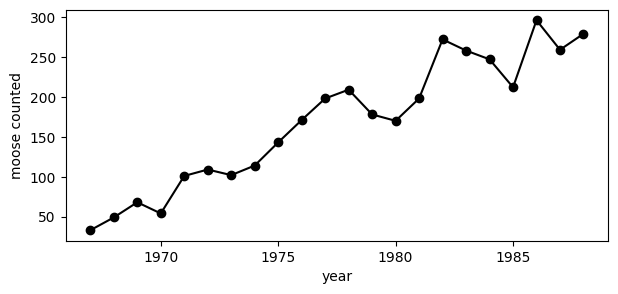

In [3]:
data = pd.read_csv("data/moose.csv")
years = data["year"].to_numpy()
counts = jnp.asarray(data["count"], dtype=jnp.float32)
YEARS = counts.shape[0]
print("years:", years[0], "to", years[-1])
print("number of counts:", YEARS)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(years, counts, "o-", color="black")
ax.set(xlabel="year", ylabel="moose counted")
plt.show()

The counts grow for about fifteen years and then level off near 250, which is the shape of a population that approaches the most animals its habitat can support.

## 2. A distribution is an object

That most animals the habitat can support is the **carrying capacity** $K$.
Before seeing the counts, we believe it is near 350 animals, within a factor of about two, which a log-normal distribution states.
In ProbPipe that distribution is an object, `LogNormal("K", ...)`, whose **component** is named `K`.

In [4]:
K = LogNormal("K", jnp.log(350.0), 0.4)
print("distribution:", K)
print("components:", list(K.event_spec.components))

distribution: LogNormal('K', loc=5.857933, scale=0.4)
components: ['K']


## 3. Operations on a distribution

An **operation** computes something about an object.
`mean` and `quantile` summarize a distribution, and `sample` draws from it.
Every operation that draws random numbers runs inside `workflow_run(seed=...)`, which makes its draws reproducible.

In [5]:
print("mean of K:", round(float(mean(K)), 1))
print("90% interval of K:", quantile(K, jnp.array([0.05, 0.95])).raw())
with workflow_run(seed=0):
    print("five draws of K:", sample(K, sample_shape=(5,)).raw())

mean of K: 379.2


90% interval of K: [181.27074 675.7846 ]
five draws of K: [243.0655  308.86386 316.67453 279.40564 353.31436]


Each operation can report how it would compute its result before it runs, through its `check`.
A log-normal distribution has a formula for its mean, so `mean` computes it exactly:

In [6]:
report = mean.check(K)
print("route:", report.route)
print("exact:", report.exact)

route: closed_form
exact: True


The route `closed_form` evaluates that formula.
Other distributions have no such formula, and an operation then estimates its result from draws, as exercise 3 shows.

## 4. A joint prior

The model has two more parameters: the growth rate $r$ of a small population, near 0.4 per year within a factor of about two, and the detection probability $\phi$, the chance that the survey finds a given animal, anywhere in $(0, 1)$ and most likely near one half.
`*` combines the three distributions into one joint distribution with three components, and indexing it by a component's name selects that component.

In [7]:
r = LogNormal("r", jnp.log(0.4), 0.4)
phi = Beta("phi", 2.0, 2.0)
prior = K * r * phi
print("components of the prior:", list(prior.event_spec.components))
prior_mean = mean(prior)
for name, value in prior_mean.items():
    print(f"{name}:", round(float(value), 3))
print("mean of the component K:", round(float(mean(prior["K"])), 1))

components of the prior: ['K', 'r', 'phi']


mean(K): 379.15
mean(r): 0.433
mean(phi): 0.5
mean of the component K: 379.2


`mean` applies to the joint as it did to `K`.
The mean of a joint is a **record**, whose fields name what they hold, such as `mean(K)`.

## 5. Labels and component names

A component name is part of the mathematics: operations match components by their names, as `prior["K"]` did.
An object also has a **label**, which names the whole object for a reader and has no mathematical meaning.
An operation gives its result a label of its own, as `*` did here, and `with_label` returns a copy under another label:

In [8]:
named_prior = prior.with_label("prior")
print("label of prior:", prior.label)
print("label of named_prior:", named_prior.label)
print("components of named_prior:", list(named_prior.event_spec.components))

label of prior: K·r·phi
label of named_prior: prior
components of named_prior: ['K', 'r', 'phi']


`prior` keeps its label: ProbPipe objects never change, and an operation or a `with_` method returns a new object.
We use `named_prior` from here on.

## 6. The Ricker model

The Ricker model describes a population $N_t$ that grows at rate $r$ when it is small and stops growing at the carrying capacity $K$:

$$N_{t+1} = N_t \exp\left(r\left(1 - \frac{N_t}{K}\right)\right).$$

We fix the population of 1966, the year before the first count, at $N_0 = 50$ animals.
The function `trajectory` computes $N_1, \dots, N_T$ with `jax.lax.scan`, which runs the recursion in a form JAX can differentiate, as the sampler of tutorial 2 needs.

In [9]:
def trajectory(r: jax.Array, K: jax.Array, n0: float, years: int) -> jax.Array:
    """The population in each of the *years* after the year of *n0*."""

    def step(N: jax.Array, _: None) -> tuple[jax.Array, jax.Array]:
        N_next = N * jnp.exp(r * (1.0 - N / K))
        return N_next, N_next

    _, N = jax.lax.scan(step, jnp.asarray(n0, dtype=jnp.float32), None, length=years)
    return N


print("population in the first five years, at r = 0.4 and K = 350:", trajectory(0.4, 350.0, 50.0, YEARS)[:5])

population in the first five years, at r = 0.4 and K = 350: [ 70.44837   96.966705 129.48288  166.59541  205.44398 ]


## 7. A conditional distribution

A survey finds each animal with probability $\phi$, so the count in year $t$ is

$$y_t \sim \text{Poisson}(\phi N_t).$$

This is the distribution of the counts given the parameters, which is a **conditional distribution**.
We write it as a Python function that returns that distribution, and `conditional_distribution` turns the function into a ProbPipe object.
`given_spec` declares its inputs, which here are the prior's components, and the function receives each input by its name.
The default `n0=50.0` is a constant of the model: no part of the model produces `n0`, so the function receives its default.

In [10]:
def ricker_counts(K: jax.Array, r: jax.Array, phi: jax.Array, n0: float = 50.0) -> Poisson:
    return Poisson("y", phi * trajectory(r, K, n0, YEARS))


likelihood = conditional_distribution(
    "counts", ricker_counts, given_spec=named_prior.event_spec.components
)
print("inputs of the likelihood:", list(likelihood.given_spec))
print("component of the likelihood:", list(likelihood.event_spec.components))

inputs of the likelihood: ['K', 'r', 'phi', 'n0']
component of the likelihood: ['y']


The likelihood's label is `counts`, and its component, the counts themselves, is `y`.

## 8. The model

`*` composes the likelihood with the prior into the **joint distribution** of the parameters and the counts, which is the model:

In [11]:
model = likelihood * named_prior
print("components of the model:", list(model.event_spec.components))

components of the model: ['y', 'K', 'r', 'phi']


`*` matched the likelihood's inputs `K`, `r`, and `phi` to the prior's components of the same names.

## 9. What the model expects

The operations of section 3 apply to the model as well.
Its draws of `y` are counts the model expects before it sees the data.
A value's `raw()` returns the array it stores, without its label and provenance, for libraries such as matplotlib.

shape of the simulated counts: (50, 22)


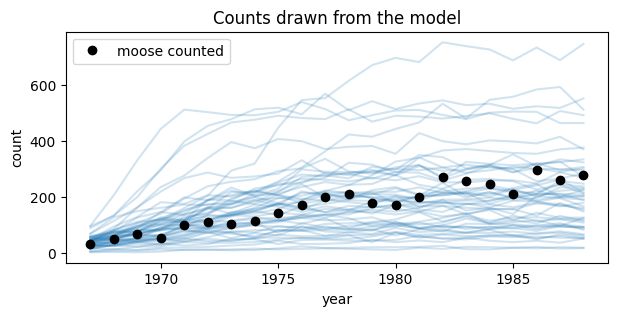

In [12]:
with workflow_run(seed=1):
    draws = sample(model, sample_shape=(50,))
simulated = draws["y"].raw()
print("shape of the simulated counts:", simulated.shape)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(years, simulated.T, color="tab:blue", alpha=0.2)
ax.plot(years, counts, "o", color="black", label="moose counted")
ax.set(xlabel="year", ylabel="count", title="Counts drawn from the model")
ax.legend()
plt.show()

The model allows a wide range of trajectories, and the observed counts lie within it.

## 10. Conditioning on parameter values

`condition_on` fixes components of a joint distribution at values and returns the distribution of the others.
Fixing the parameters gives the distribution of the counts at those values:

In [13]:
values = {"K": 350.0, "r": 0.4, "phi": 0.6}
report = condition_on.check(model, values)
print("route:", report.route)
print("exact:", report.exact)

counts_at_values = condition_on(model, values)
print("distribution of the counts at those values:", type(counts_at_values).__name__)

route: slice
exact: True


distribution of the counts at those values: Poisson


The route `slice` computes the answer from the model's parts.
Given the parameters, the counts follow the likelihood, so the result is the Poisson distribution of the counts at those values, which is exact.

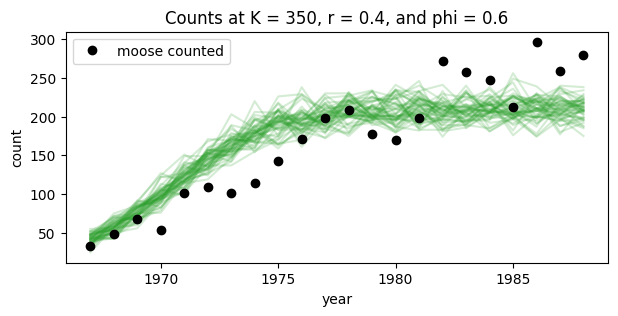

In [14]:
with workflow_run(seed=2):
    at_values = sample(counts_at_values, sample_shape=(50,)).raw()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(years, at_values.T, color="tab:green", alpha=0.2)
ax.plot(years, counts, "o", color="black", label="moose counted")
ax.set(xlabel="year", ylabel="count", title="Counts at K = 350, r = 0.4, and phi = 0.6")
ax.legend()
plt.show()

At these values the counts rise faster than the observed ones in the early 1970s, and they level off near 210, below the counts of the 1980s.
[Tutorial 2](02_fitting.ipynb) conditions the same model on the counts instead, which gives the distribution of the parameters that the counts support.

## Exercises

Each exercise is followed by a solution, which Colab shows collapsed.

**Exercise 1.** Draw the counts at a carrying capacity of 250 and of 450, with $r = 0.4$ and $\phi = 0.6$.
Which carrying capacity agrees better with the counts after 1980?

In [15]:
# @title Solution
late = years > 1980
for capacity in [250.0, 450.0]:
    at_capacity = condition_on(model, {"K": capacity, "r": 0.4, "phi": 0.6})
    expected = mean(at_capacity).raw()
    print(f"K = {capacity:.0f}: mean count after 1980 {expected[late].mean():.0f}, observed {counts[late].mean():.0f}")

K = 250: mean count after 1980 150, observed 253
K = 450: mean count after 1980 269, observed 253


**Exercise 2.** A survey team believes it finds about two thirds of the animals.
Give $\phi$ the prior `Beta("phi", 8.0, 4.0)`, whose mean is 2/3, and draw the counts from the new model.
How does the range of the counts change?

In [16]:
# @title Solution
informed_prior = (K * r * Beta("phi", 8.0, 4.0)).with_label("informed prior")
informed_model = likelihood * informed_prior
with workflow_run(seed=3):
    informed = sample(informed_model, sample_shape=(1000,))["y"].raw()
    original = sample(model, sample_shape=(1000,))["y"].raw()
print("90% range of the 1988 count, Beta(2, 2):", jnp.quantile(original[:, -1], jnp.array([0.05, 0.95])))
print("90% range of the 1988 count, Beta(8, 4):", jnp.quantile(informed[:, -1], jnp.array([0.05, 0.95])))

90% range of the 1988 count, Beta(2, 2): [ 40.      425.19995]
90% range of the 1988 count, Beta(8, 4): [102.      489.09998]


**Exercise 3.** Apply `quantile` to the model's counts, `model["y"]`, and print the route that `quantile.check` reports.
Why is it not `closed_form`, as it was for `K`?

In [17]:
# @title Solution
levels = jnp.array([0.05, 0.95])
report = quantile.check(model["y"], levels)
print("route:", report.route)
print("exact:", report.exact)
with workflow_run(seed=4):
    print("90% interval of the 1988 count:", quantile(model["y"], levels).raw()[:, -1])
# The counts' distribution under the model has no formula for its quantiles, so
# `quantile` estimates them from draws, by the route `monte_carlo`.

route: monte_carlo
exact: False


90% interval of the 1988 count: [ 31. 385.]


## Summary

- Distributions, such as the prior of $K$, are objects, and so are conditional distributions, such as the likelihood written as a Python function.
- `*` composes objects into a joint distribution, matching components by name, and the model is the joint distribution of the parameters and the counts.
- The operations `mean`, `quantile`, `sample`, and `condition_on` apply alike to a single distribution, to the prior, and to the model.
- Each operation computes exactly when it can, as `mean` of `K` and `condition_on` at parameter values did, and `check` reports the route it takes.

[Tutorial 2](02_fitting.ipynb) fits the model to the counts.

## References

- Ricker, W. E. (1954). Stock and recruitment. *Journal of the Fisheries Research Board of Canada*, 11(5), 559–623.
- Dietze, M. C. (2017). *Ecological Forecasting*. Princeton University Press. The moose counts are the `alcesdata` census of its [course materials](https://github.com/mdietze/EE509).